In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from fismi import ismiReplication as fismi
from fismi import utils
from fismi import figures
from fismi import maths
import statsmodels.api as sm
import seaborn as sns

In [2]:
# Import data
niv = '2'

# Unchained other items 
dfICP = pd.read_parquet(f"input/USItemsLvl{niv}.parquet")
dfW = pd.read_parquet(f"input/USnormedWeightsLvl{niv}.parquet") 

# We compute headline inflation (PCE variation over a 12-month period)
headline = (np.log(dfICP["Personal consumption expenditures"]).diff(12)[1:]*100)  # Inflation headline annuelle glissante

# We compute monthly inflation rates
dfInflation = (np.log(dfICP).diff(1)[1:]*100)
InflTot = dfInflation["Personal consumption expenditures"].to_frame()           # To replicate Figure A1
dfInflation = dfInflation.drop("Personal consumption expenditures",axis=1)

# Drop series
if niv=='4':
    colToDrop = ["Internet access (72)","Video and audio streaming and rental"]
    dfInflation = dfInflation.loc[:, ~dfInflation.columns.isin(colToDrop)]
    dfW = dfW.loc[:, ~dfW.columns.isin(colToDrop)]

In [12]:
dfInflation

LineDescription,Clothing and footwear,Financial services and insurance,Food and beverages purchased for off-premises consumption,Food services and accommodations,Furnishings and durable household equipment,Gasoline and other energy goods,Health care,Housing and utilities,Motor vehicles and parts,Other durable goods,Other nondurable goods,Other services,Recreation services,Recreational goods and vehicles,Transportation services
TIME_PERIOD,,,,,,,,,,,,,,,
1959-02-01,-0.021485,0.201552,-0.381167,0.515520,-0.054916,1.961640,0.183655,0.078771,0.148945,0.153073,-0.012962,-0.046942,0.524936,0.003019,0.257636
1959-03-01,0.058583,0.000000,-0.194266,0.171251,0.090330,-0.050078,0.165001,0.078709,0.264245,-0.038996,0.084221,0.112623,0.746302,-0.084553,0.471992
1959-04-01,0.167749,-0.171293,-0.276382,0.628966,0.288157,0.668966,0.438677,0.410033,0.095616,0.089969,0.400699,-0.037527,0.653441,-0.309831,0.288720
1959-05-01,0.109081,-0.050436,-0.226700,0.572217,0.137598,-0.548821,0.509370,0.078326,0.322443,-0.020985,0.219058,-0.131455,0.158730,-0.106423,0.107027
1959-06-01,0.101183,0.131081,0.339858,0.232190,0.184929,-0.411090,0.289908,0.425366,0.390145,-0.020990,0.462310,0.515441,0.656051,-0.180967,0.254756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-01,1.031401,0.579924,-0.140881,0.244304,-0.503727,18.991255,0.347275,0.285245,-0.076595,0.607112,-0.329704,0.068231,0.273463,1.500842,1.286493
2026-04-01,0.403097,-0.105614,0.488805,0.531860,-0.130688,5.348139,0.079969,0.619984,-0.094047,1.006026,-0.104705,-0.118621,0.335203,1.608815,0.378337
2026-05-01,0.040871,1.275812,0.059891,0.298546,-0.430736,6.275965,0.295895,0.308901,-0.193905,0.820787,-0.256216,0.653912,0.205037,0.093963,0.856462


PACF values: [1.         0.69219064 0.16251285 0.17677415 0.15871228 0.11770623
 0.1266296  0.09382876 0.04322784 0.10231276 0.06992627]


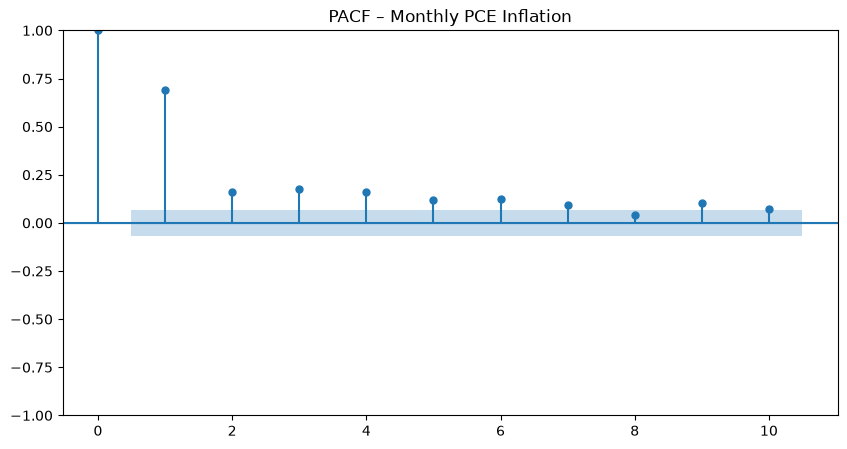

In [3]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf

# Série propre
x = InflTot.dropna()

# Valeurs numériques
pacf_values = pacf(x, nlags=10, method="ywm")
print("PACF values:", pacf_values)

# Graphique : on passe InflTot, PAS pacf_values
fig, ax = plt.subplots(figsize=(10, 5))

plot_pacf(
    x,
    lags=10,
    method="ywm",
    ax=ax
)

ax.axhline(0, linewidth=0.8)
ax.set_title("PACF – Monthly PCE Inflation")

plt.show()

In [4]:
# Initial parameters
pi = headline.dropna().values/100
# pi = InflTot.iloc[:,0].values

F = 0.9
mu = pi.mean()            
rho_bar = 0.5
D = pi.std()              
B = 0.2

X0 = [mu, rho_bar, F, D, B]
M = 1
mu, rho_bar, F, H, Q = maths.get_parameters(X0, M)

print(f"Average monthly inflation : {mu}")
print(f"Long-run persistence : {rho_bar}")
print(f"AR(1) state coefficient (inertial persistence) : {F}")
print(f"Measurement error variance : {H}")
print(f"Variance of the state innovations : {Q}")

Average monthly inflation : 0.03208714412701736
Long-run persistence : 0.5
AR(1) state coefficient (inertial persistence) : 0.9
Measurement error variance : 0.0005156385986125032
Variance of the state innovations : 0.04000000000000001


In [5]:
# Optimise...
res = maths.optNegLogLike(X0, pi)
res

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -3634.9531578385677
        x: [ 3.209e-02  5.000e-01  9.990e-01  2.294e-03  1.434e-02]
      nit: 15
      jac: [ 0.000e+00  0.000e+00 -7.752e+03  1.592e-03  0.000e+00]
     nfev: 186
     njev: 31
 hess_inv: <5x5 LbfgsInvHessProduct with dtype=float64>

In [6]:
# Get parameters...
print("Optimisation successful...")
_, _, F, H, Q = maths.get_parameters(res.x, M)
print(f"AR(1) state coefficient (inertial persistence) : {F}")
print(f"Measurement error variance : {H}")
print(f"Variance of the state innovations : {Q}")

Optimisation successful...
AR(1) state coefficient (inertial persistence) : 0.999
Measurement error variance : 5.264666982218048e-06
Variance of the state innovations : 0.00020563040775104608


In [7]:
# Filter...
results = maths.kalman_filter_inflation(res.x, pi, return_loglik=False)


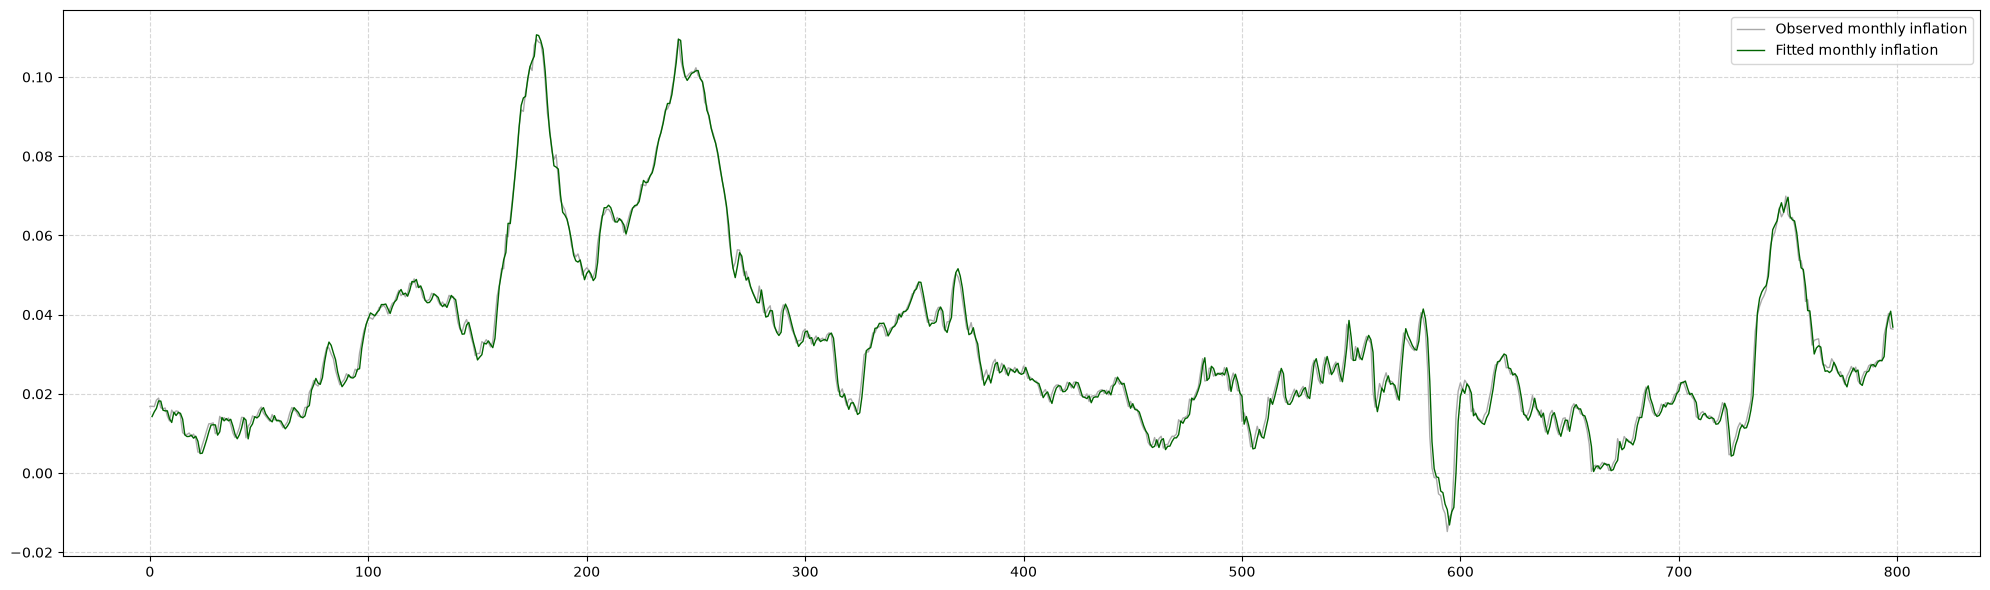

In [8]:
# Inflation versus predicted
fitted = results["FittedY"]
pi = results["Y"]
xAxis = headline.index

fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(
    pi,
    label=f"Observed monthly inflation",
    color="darkgrey",
    linewidth=1,
)

ax.grid(True, linestyle="--", alpha=0.5)

ax.plot(
    fitted,
    label=f"Fitted monthly inflation",
    color="darkgreen",
    linewidth=1,
)

plt.legend()
plt.tight_layout()
plt.show()


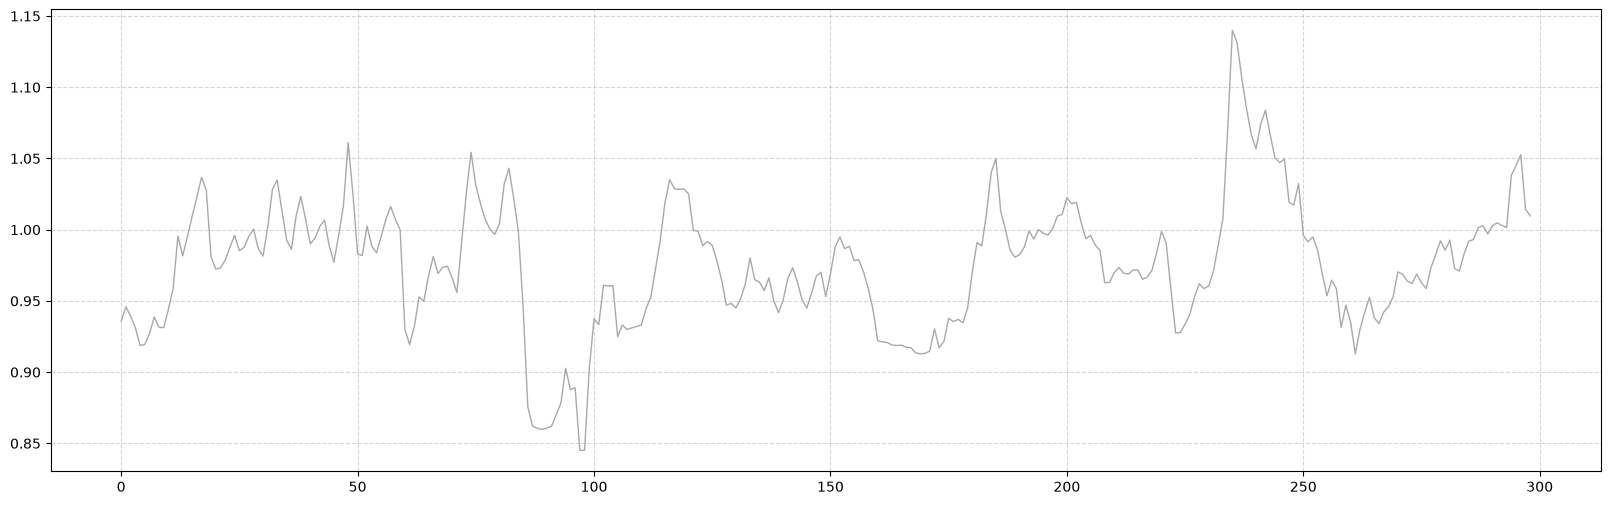

In [11]:
# Inflation versus predicted
Rho = results["Rho"]
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(
    # xAxis[500:],
    Rho[500:],
    color="darkgrey",
    linewidth=1,
)

ax.grid(True, linestyle="--", alpha=0.5)

In [ ]:
xAxis

DatetimeIndex(['1959-02-01', '1959-03-01', '1959-04-01', '1959-05-01',
               '1959-06-01', '1959-07-01', '1959-08-01', '1959-09-01',
               '1959-10-01', '1959-11-01',
               ...
               '2025-10-01', '2025-11-01', '2025-12-01', '2026-01-01',
               '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01',
               '2026-06-01', '2026-07-01'],
              dtype='datetime64[ns]', name='TIME_PERIOD', length=810, freq=None)

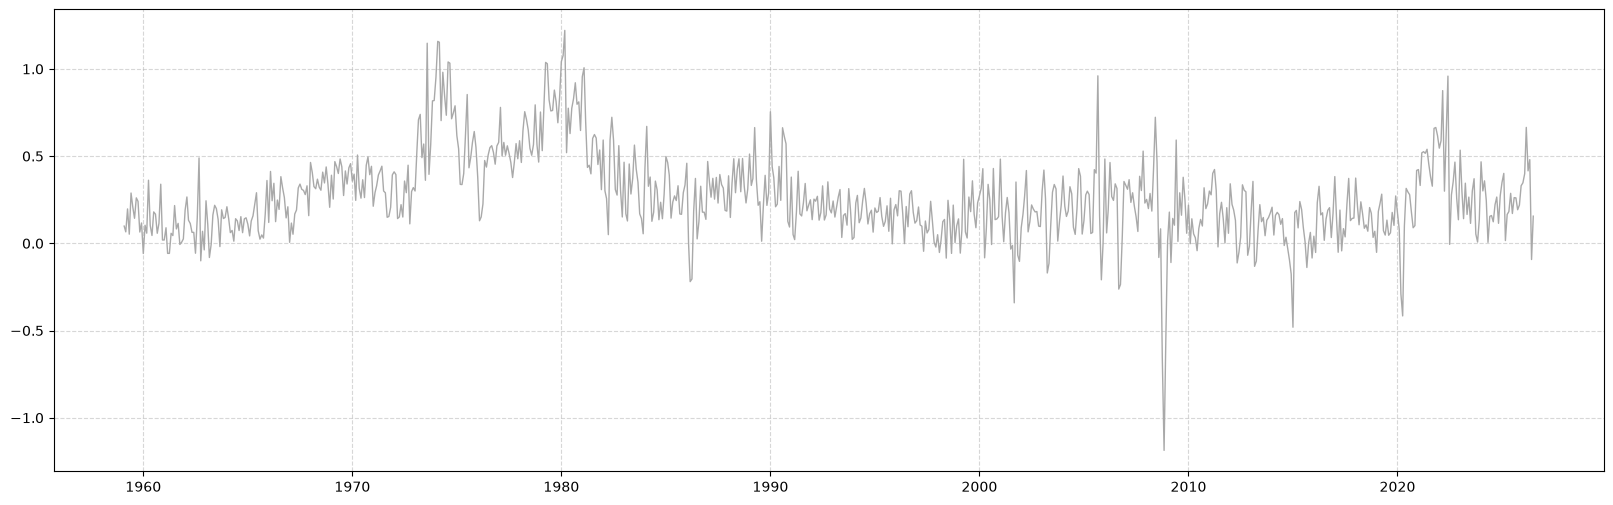

In [ ]:
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(
    xAxis,
    InflTot.values,
    color="darkgrey",
    linewidth=1,
)

ax.grid(True, linestyle="--", alpha=0.5)